# Dealing With Missing Values 

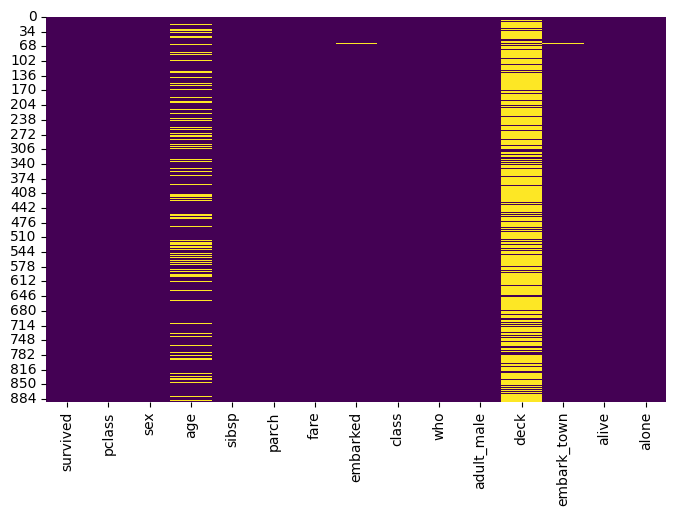

In [2]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load titanic dataset
df= sns.load_dataset('titanic')
# visualize the data 
plt.figure(figsize=(8,5))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.show()

In [14]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
df.isnull().sum().sort_values(ascending=False)

deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [5]:
(df.isnull().sum()/len(df)*100).sort_values(ascending=False)

deck           77.216611
age            19.865320
embarked        0.224467
embark_town     0.224467
sex             0.000000
pclass          0.000000
survived        0.000000
fare            0.000000
parch           0.000000
sibsp           0.000000
class           0.000000
adult_male      0.000000
who             0.000000
alive           0.000000
alone           0.000000
dtype: float64

In [16]:
# mean and median of age column 
print(f"Mean of age : {df['age'].mean():.3f}")
print(f"Median of age : {df['age'].median():.3f}")

Mean of age : 29.362
Median of age : 28.000


In [15]:
df['age'].fillna(df['age'].median(),inplace=True)

In [19]:
df.isnull().sum().sort_values(ascending=False)

deck           688
embarked         2
embark_town      2
age              0
survived         0
pclass           0
sex              0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

In [20]:
# drop the deck column 
df.drop(columns='deck',axis=1,inplace=True)

In [21]:
df.isnull().sum().sort_values(ascending=False)

embark_town    2
embarked       2
sex            0
age            0
survived       0
pclass         0
parch          0
sibsp          0
class          0
fare           0
who            0
adult_male     0
alive          0
alone          0
dtype: int64

In [26]:
df['embark_town'].value_counts()

embark_town
Southampton    644
Cherbourg      168
Queenstown      77
Name: count, dtype: int64

In [25]:
print(f"Mode of embarked : {df['embarked'].mode()[0]}")
print(f"Mode of embark_town : {df['embark_town'].mode()[0]}")


Mode of embarked : S
Mode of embark_town : Southampton


In [27]:
# replace null values with mode 
df['embarked'].fillna(df['embarked'].mode()[0],inplace=True)
df['embark_town'].fillna(df['embark_town'].mode()[0],inplace=True)

# Sklearn Simple Imputer 

In [48]:
# import libraries
import pandas as pd
from sklearn.impute import SimpleImputer

# load titanic dataset
df= sns.load_dataset('titanic')
print(f"Age Missing Values Before Simple Imputer : {df['age'].isnull().sum()}")
# impute age column using simpleimputer from sklearn
imputer = SimpleImputer(strategy='median')
df['age'] = imputer.fit_transform(df[['age']])
print(f"Age Missing Values After Simple Imputer : {df['age'].isnull().sum()}")

Age Missing Values Before Simple Imputer : 177
Age Missing Values After Simple Imputer : 0


# Sklearn Multi-Variate imputer 

In [47]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df = sns.load_dataset('titanic')
print(f"Age Missing Values Before Iterative Imputer : {df['age'].isnull().sum()}")
imputer = IterativeImputer(max_iter=10,n_nearest_features=5)
df['age']= imputer.fit_transform(df[['age']])
print(f"Age Missing Values After Iterative Imputer : {df['age'].isnull().sum()}")

Age Missing Values Before Iterative Imputer : 177
Age Missing Values After Iterative Imputer : 0


# Sklearn Forward/Backward Fill

In [45]:
df= sns.load_dataset('titanic')
print(f"Age Missing Values Before Forward Fill : {df['age'].isnull().sum()}")
df['age'] = df['age'].ffill()
print(f"Age Missing Values After Forward Fill : {df['age'].isnull().sum()}")

Age Missing Values Before Forward Fill : 177
Age Missing Values After Forward Fill : 0


In [46]:
df= sns.load_dataset('titanic')
print(f"Age Missing Values Before backward Fill : {df['age'].isnull().sum()}")
df['age'] = df['age'].bfill()
print(f"Age Missing Values After backward Fill : {df['age'].isnull().sum()}")

Age Missing Values Before backward Fill : 177
Age Missing Values After backward Fill : 0


# KNN Imputer 

In [50]:
from sklearn.impute import KNNImputer 

df = sns.load_dataset('titanic')
print(f"Age Nan Before KNN Imputer : {df['age'].isnull().sum()}")

imputer = KNNImputer(n_neighbors=5)
df['age'] = imputer.fit_transform(df[['age']])
print(f"Age Nan After KNN Imputer : {df['age'].isnull().sum()}")

Age Nan Before KNN Imputer : 177
Age Nan After KNN Imputer : 0
